In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

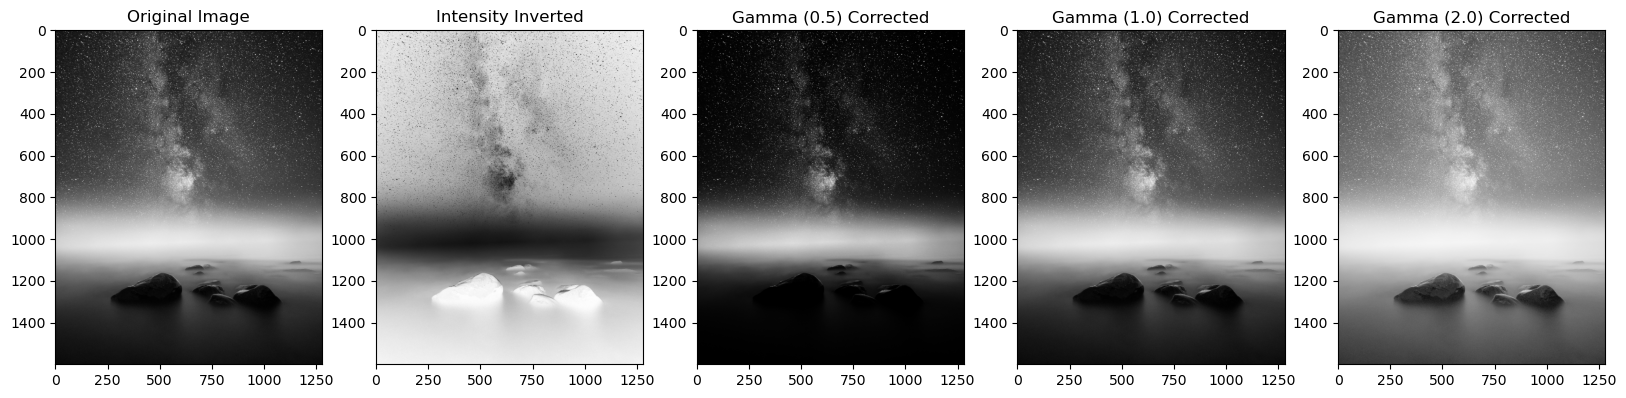

In [3]:
### Brightness Alternation ###
def intensity_inversion(image):
    # inverts the pixel values, meaning that dark pixels become bright and bright pixels become dark.
    return cv2.bitwise_not(image)

def gamma_correction(image, gamma=2.2):
    invGamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** invGamma * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(image, table)

image = cv2.imread("images/image1.jpg")  # Replace with the uploaded file name
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
inverted = intensity_inversion(image_gray)
gamma_corrected_0 = gamma_correction(image_gray, gamma=0.5)
gamma_corrected_1 = gamma_correction(image_gray, gamma=1)
gamma_corrected_2 = gamma_correction(image_gray, gamma=2)

# Display Results
fig, ax = plt.subplots(1, 5, figsize=(20, 15))
ax[0].imshow(image_gray, cmap='gray'); ax[0].set_title("Original Image")
ax[1].imshow(inverted, cmap='gray'); ax[1].set_title("Intensity Inverted")
ax[2].imshow(gamma_corrected_0, cmap='gray'); ax[2].set_title("Gamma (0.5) Corrected")
ax[3].imshow(gamma_corrected_1, cmap='gray'); ax[3].set_title("Gamma (1.0) Corrected")
ax[4].imshow(gamma_corrected_2, cmap='gray'); ax[4].set_title("Gamma (2.0) Corrected")
plt.show()

#Reference: https://pyimagesearch.com/2015/10/05/opencv-gamma-correction/

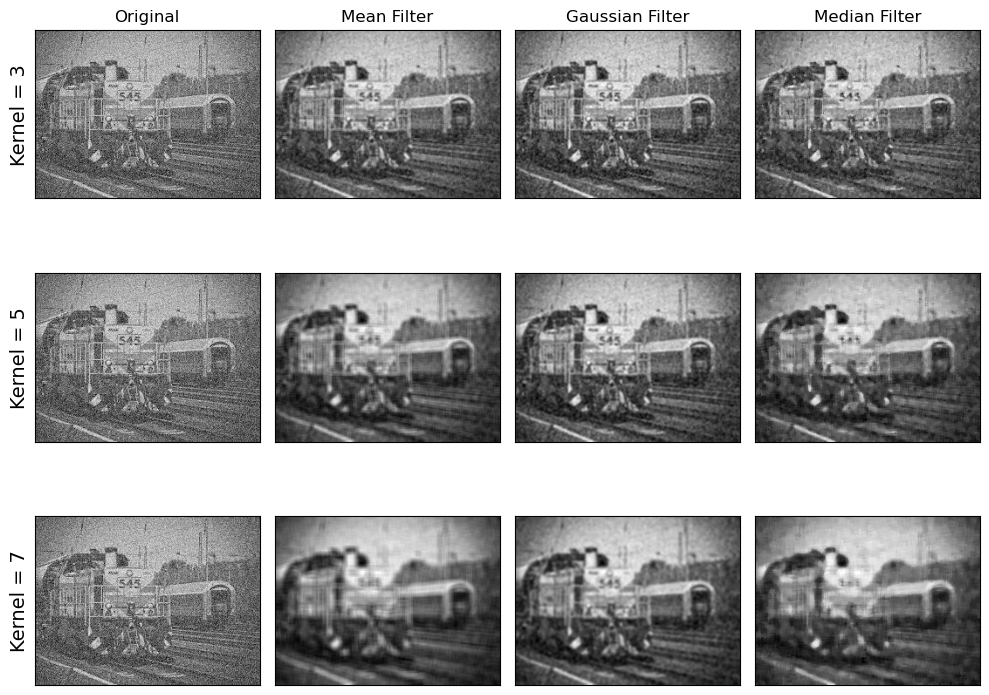

In [6]:
### Noise Reduction ###

# Function to apply different filters
def apply_filtering(img, kernel_size):
    mean_filtered = cv2.blur(img, (kernel_size, kernel_size))  # Mean filter
    gaussian_filtered = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)  # Gaussian filter
    median_filtered = cv2.medianBlur(img, kernel_size)  # Median filter
    return mean_filtered, gaussian_filtered, median_filtered

# Load the noisy image (Change 'noisy_image.jpg' to your actual file)
image = cv2.imread("images/image2.jpeg", cv2.IMREAD_GRAYSCALE)

# Define kernel sizes to test
kernel_sizes = [3, 5, 7]

# Create figure for visualization
fig, axes = plt.subplots(3, 4, figsize=(10, 8))

# Titles for each column
titles = ["Original", "Mean Filter", "Gaussian Filter", "Median Filter"]

# Apply filters and plot images
for i, kernel_size in enumerate(kernel_sizes):
    mean_filtered, gaussian_filtered, median_filtered = apply_filtering(image, kernel_size)

    # Display images
    axes[i, 0].imshow(image, cmap='gray')
    axes[i, 1].imshow(mean_filtered, cmap='gray')
    axes[i, 2].imshow(gaussian_filtered, cmap='gray')
    axes[i, 3].imshow(median_filtered, cmap='gray')

    # Set column titles only for the first row
    if i == 0:
        for j in range(4):
            axes[i, j].set_title(titles[j], fontsize=12)
    axes[i, 0].set_ylabel(f"Kernel = {kernel_size}", fontsize=14)

    for j in range(4):
        axes[i, j].set_xticks([])  # Hide x-axis ticks
        axes[i, j].set_yticks([])  # Hide y-axis ticks

plt.tight_layout()
plt.show()

# Reference: https://pyimagesearch.com/2021/04/28/opencv-smoothing-and-blurring/

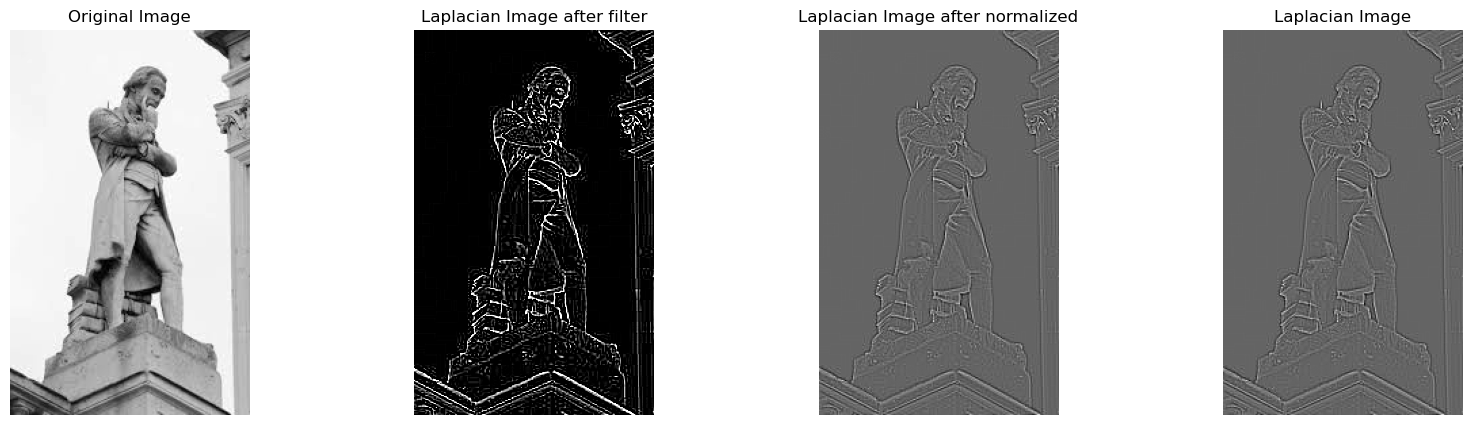

In [10]:
# Read the input image
image_path = 'images/Laplace.jpg' #Insert your Input Path here
input_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
laplacian_kernel = np.array([[1, 1, 1],
                             [1, -8, 1],
                             [1, 1, 1]], dtype=np.float32)
laplacian_image_filter = cv2.filter2D(input_image, cv2.CV_32F, laplacian_kernel)
laplacian_image_normalized = cv2.normalize(laplacian_image_filter, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
laplacian_image = laplacian_image_normalized.astype(np.uint8)
# Display the original and Laplacian images
plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1)
plt.title('Original Image')
plt.imshow(input_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Laplacian Image after filter')
plt.imshow(laplacian_image_filter, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('Laplacian Image after normalized')
plt.imshow(laplacian_image_normalized, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Laplacian Image')
plt.imshow(laplacian_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.show()

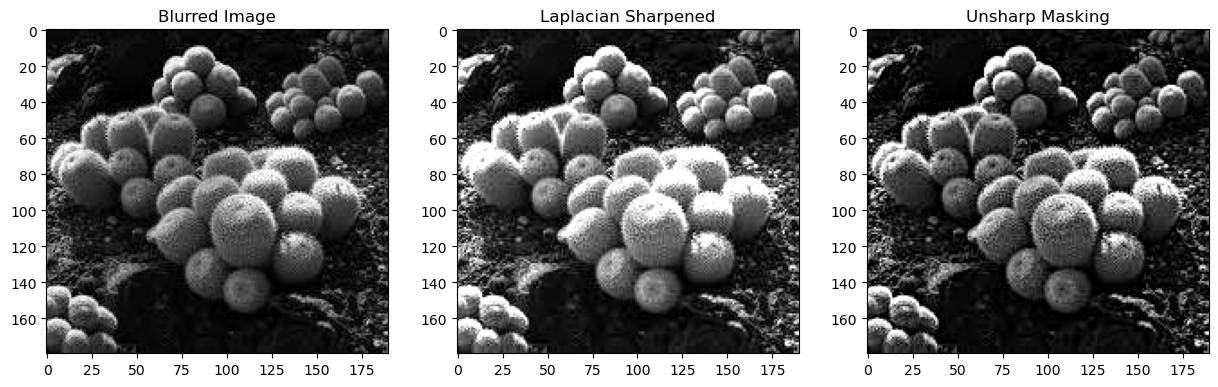

In [11]:
### Image Sharpening ###
def sharpen_laplacian(image):
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    laplacian = np.clip(laplacian, 0, 255).astype(np.uint8)
    sharpened = cv2.addWeighted(image, 1.5, laplacian, -0.0, 0)
    return sharpened

def sharpen_unsharp_mask(image):
    gaussian_blur = cv2.GaussianBlur(image, (9,9), 10)
    sharpened = cv2.addWeighted(image, 1.5, gaussian_blur, -0.5, 0)
    return sharpened

blurred_image = cv2.imread("images/image3.jpeg", cv2.IMREAD_GRAYSCALE)
laplacian_sharp = sharpen_laplacian(blurred_image)
unsharp_sharp = sharpen_unsharp_mask(blurred_image)

# Display Results
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(blurred_image, cmap='gray'); ax[0].set_title("Blurred Image")
ax[1].imshow(laplacian_sharp, cmap='gray'); ax[1].set_title("Laplacian Sharpened")
ax[2].imshow(unsharp_sharp, cmap='gray'); ax[2].set_title("Unsharp Masking")
plt.show()


# Types of Image Processing

## 1. Spatial Domain Operations

### 1.1 Point Operations (Pixel-wise Operations)

- **Contrast Stretching**  
  Best used when an image has low contrast and occupies only a small portion of the available intensity range.

- **Intensity Thresholding**  
  Best used when the object and background can be separated by a single intensity cutoff.

- **Multilevel Thresholding**  
  Best used when the image contains multiple distinct intensity regions that need to be segmented separately.

- **Intensity Inversion**  
  Best used when swapping dark and bright regions improves visual interpretation or matches analysis requirements.

- **Log Transformation**  
  Best used to enhance details in dark regions while compressing bright intensity values.

- **Power Transformation (Gamma Correction)**  
  Best used to adjust overall image brightness or correct non-linear display responses.

- **Otsu Thresholding**  
  Best used when automatic threshold selection is required for images with a bimodal intensity histogram.

- **Piecewise Contrast Stretching**  
  Best used when different intensity ranges need selective enhancement while preserving others.

- **Gray-Level Slicing**  
  Best used to highlight a specific intensity range while suppressing the rest of the image.

- **Histogram Equalization**  
  Best used when you want to improve global contrast in images with uneven intensity distribution.

- **Histogram Matching**  
  Best used when you want one image to have a similar intensity distribution to a reference image.


### 1.2 Neighbourhood Operations (Group-wise Operations)

- **Uniform Filter (Mean Filter)**  
  Best used for simple smoothing when you want to reduce random noise but can tolerate some blurring.

- **Gaussian Filter**  
  Best used for noise reduction when smoother results with less edge distortion than uniform filtering are desired.

- **Median Filter**  
  Best used to remove salt-and-pepper (impulse) noise while preserving edges.

- **Unsharp Masking**  
  Best used to enhance edges and improve image sharpness after smoothing or blurring.

- **Prewitt Filtering**  
  Best used to detect edges by approximating first-order intensity derivatives in horizontal and vertical directions.

- **Laplacian Filtering**  
  Best used to detect edges or fine details by highlighting regions of rapid intensity change using second-order derivatives.


## 2. Transform Domain Operations

- **Low-Pass Filtering**  
  Best used to remove high-frequency noise and smooth an image by preserving only low-frequency components.

- **High-Pass Filtering**  
  Best used to enhance edges and fine details by retaining high-frequency components and suppressing smooth regions.

- **Difference of Gaussian (DoG)**  
  Best used for edge and blob detection by approximating a band-pass filter that highlights structures at specific scales.